1. Introducción 

El dataset que se utilizará para la practica fue: Social Media Usage and Emotional Well-Being  (https://www.kaggle.com/datasets/emirhanai/social-media-usage-and-emotional-well-being)

Este dataset es de datos único y fue meticulosamente investigado y preparado por el inventor de IA Emirhan BULUT.

Captura información valiosa sobre el uso de las redes sociales y el estado emocional predominante de los usuarios según sus actividades.

Caracteristicas:

- **User_ID**: Identificador único del usuario.
- **Age**: Edad del usuario..
- **Gender**: Género del usuario (Femenino, Masculino, No binario).
- **Platform**: Plataforma de redes sociales utilizada (por ejemplo, Instagram, - Twitter, Facebook, LinkedIn, Snapchat, Whatsapp, Telegram).
- **Daily_Usage_Time (minutes)**: Tiempo diario dedicado a la plataforma en minutos.
- **Posts_Per_Day**: Número de publicaciones realizadas por día.
- **Likes_Received_Per_Day**: Número de "me gusta" recibidos por día.
- **Comments_Received_Per_Day**: Número de comentarios recibidos por día.
- **Messages_Sent_Per_Day**: Número de mensajes enviados por día.
- **Dominant_Emotion**: estado emocional dominante del usuario durante el día (por ejemplo, felicidad, tristeza, ira, ansiedad, aburrimiento, neutral).

Asi mismo el dataset consta de 3 archivos en los cuales esta divido de la siguiente manera:

Archivos:

- train.csv : Datos para el entrenamiento de modelos.
- test.csv : Datos para probar los modelos.
- val.csv : Datos para fines de validación.

Para esta práctica se utilizó el archivo de train.csv

2. Importar librerias

In [4]:
#Importamos las librerias

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

3. Cargamos el dataset

In [6]:
# Cargamos el dataset

df = pd.read_csv("train.csv")
df.head()

,User_ID,Age,Gender,Platform,Daily_Usage_Time (minutes),Posts_Per_Day,Likes_Received_Per_Day,Comments_Received_Per_Day,Messages_Sent_Per_Day,Dominant_Emotion
0,1,25,Female,Instagram,120.0,3.0,45.0,10.0,12.0,Happiness
1,2,30,Male,Twitter,90.0,5.0,20.0,25.0,30.0,Anger
2,3,22,Non-binary,Facebook,60.0,2.0,15.0,5.0,20.0,Neutral
3,4,28,Female,Instagram,200.0,8.0,100.0,30.0,50.0,Anxiety
4,5,33,Male,LinkedIn,45.0,1.0,5.0,2.0,10.0,Boredom


In [7]:
#Revisamos la estructura del dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   User_ID                     1001 non-null   object 
 1   Age                         1001 non-null   object 
 2   Gender                      1000 non-null   object 
 3   Platform                    1000 non-null   object 
 4   Daily_Usage_Time (minutes)  1000 non-null   float64
 5   Posts_Per_Day               1000 non-null   float64
 6   Likes_Received_Per_Day      1000 non-null   float64
 7   Comments_Received_Per_Day   1000 non-null   float64
 8   Messages_Sent_Per_Day       1000 non-null   float64
 9   Dominant_Emotion            1000 non-null   object 
dtypes: float64(5), object(5)
memory usage: 78.3+ KB


In [8]:
#Verficamos cuantas columnas y filas tiene el dataset

df.shape

(1001, 10)

In [9]:
#Verificamos estadisticas descriptivas del dataset

df.describe()

,Daily_Usage_Time (minutes),Posts_Per_Day,Likes_Received_Per_Day,Comments_Received_Per_Day,Messages_Sent_Per_Day
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,95.950000,3.321000,39.898000,15.611000,22.560000
std,38.850442,1.914582,26.393867,8.819493,8.516274
min,40.000000,1.000000,5.000000,2.000000,8.000000
25%,65.000000,2.000000,20.000000,8.000000,17.750000
50%,85.000000,3.000000,33.000000,14.000000,22.000000
75%,120.000000,4.000000,55.000000,22.000000,28.000000
max,200.000000,8.000000,110.000000,40.000000,50.000000


Se puede identificar en la estructura del dataset lo siguiente:

El conjunto de datos contiene 1001 registros y 10 columnas relacionadas con el comportamiento de usuarios en redes sociales, incluyendo edad, género, plataforma utilizada, tiempo de uso diario, publicaciones, interacciones y emoción dominante. Además, se observó que la mayoría de las variables numéricas están almacenadas en formato float64, mientras que las variables categóricas se encuentran en formato object.

También se detectaron algunos valores faltantes en columnas como Gender, Platform y otras variables, por lo que será necesario realizar una limpieza de datos antes del análisis final

Asi mismo en el cuadro de estadísticas descriptiva, se observa que los usuarios dedican en promedio aproximadamente 96 minutos diarios al uso de redes sociales. Además, realizan cerca de 3 publicaciones por día y reciben alrededor de 40 “likes” diarios. En cuanto a la interacción, los usuarios reciben un promedio de 16 comentarios y envían aproximadamente 23 mensajes por día.

4. Limpieza del dataset

In [10]:
#Verificamos los valores nulos

df.isnull().sum()

User_ID                       0
Age                           0
Gender                        1
Platform                      1
Daily_Usage_Time (minutes)    1
Posts_Per_Day                 1
Likes_Received_Per_Day        1
Comments_Received_Per_Day     1
Messages_Sent_Per_Day         1
Dominant_Emotion              1
dtype: int64

Al analizar los valores nulos del dataset, se identificó que las siguientes columnas presentan 1 dato faltante:

- Gender
- Platform
- Daily_Usage_Time (minutes)
- Posts_Per_Day
- Likes_Received_Per_Day
- Comments_Received_Per_Day
- Messages_Sent_Per_Day
- Dominant_Emotion

Mientras que las siguientes columnas no presentan datos faltantes:

- User_ID
- Age
    
Despues de analizar los valores faltantes se decidio realizar un proceso de limpieza de esos datos para garantizar la calidad y consistencia de la información utilizada.

In [7]:
# Eliminamos las filas con datos faltantes

df = df.dropna()

In [8]:
# Verificamos que no existan valores nulos

df.isnull().sum()

User_ID                       0
Age                           0
Gender                        0
Platform                      0
Daily_Usage_Time (minutes)    0
Posts_Per_Day                 0
Likes_Received_Per_Day        0
Comments_Received_Per_Day     0
Messages_Sent_Per_Day         0
Dominant_Emotion              0
dtype: int64

In [12]:
#Volvemos a verificar las columnas y filas
df.shape

(1001, 10)

Despues de la limpieza se puede observar que el dataset quedo compuesto por 1000 registros y 10 columnas.

5. Visualización

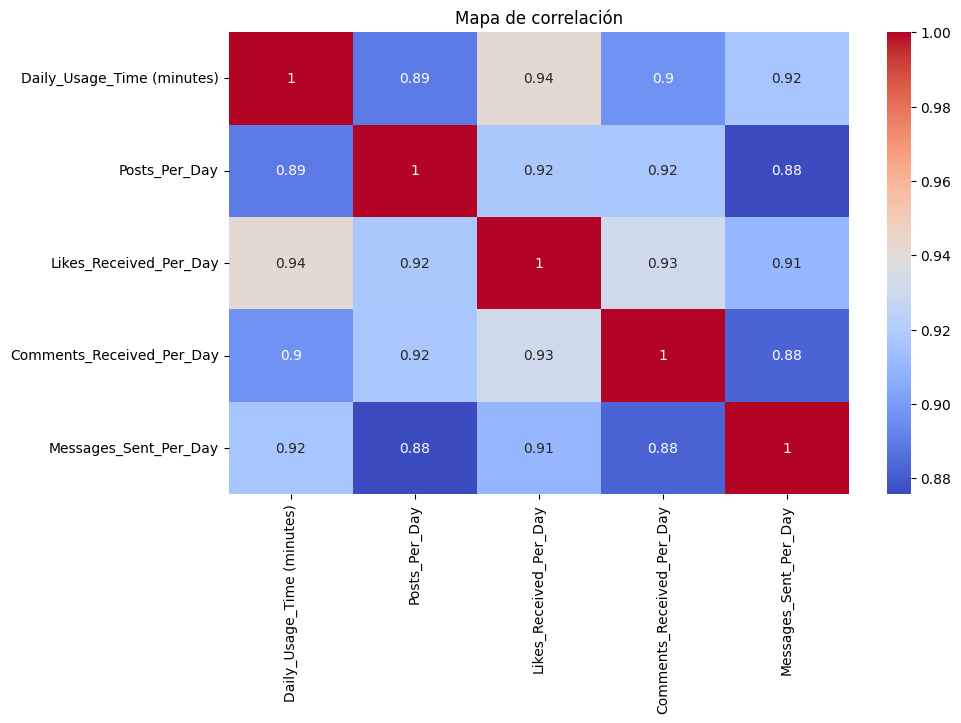

In [13]:
#Mapa de correlación

plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title('Mapa de correlación')
plt.show()

- Se puede observar en el mapa de correlación que muestra relaciones positivas fuertes entre las variables numéricas del dataset. La correlación más alta se presenta entre Daily_Usage_Time y Likes_Per_Day con un valor de 0.94, lo que puede determinar que los usuarios que pasan más tiempo en redes sociales tienden a recibir una mayor cantidad de “likes” en sus publicaciones.

- Las variables Likes_Per_Day y Comments_Per_Day tienen una correlación de 0.93, evidenciando que las publicaciones con más “likes” también suelen generar más comentarios e interacción por parte de otros usuarios.


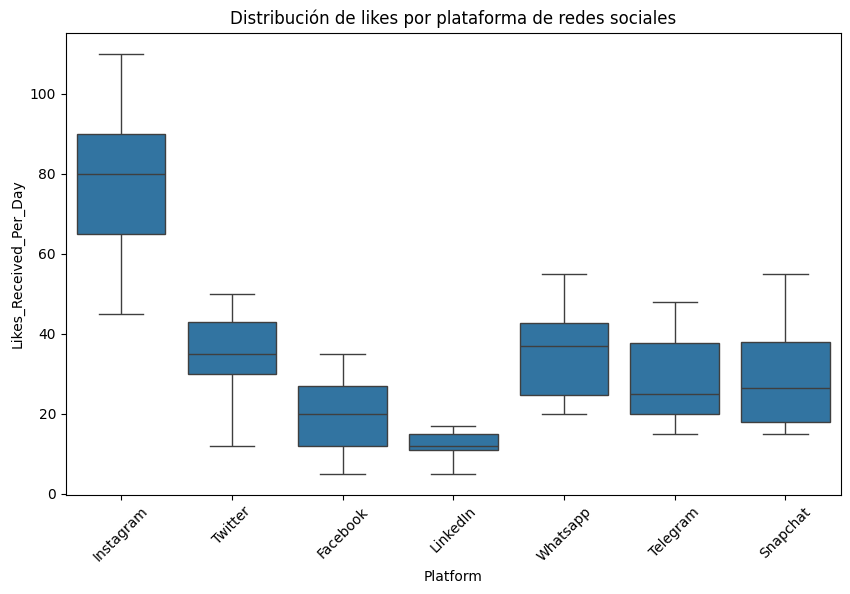

In [17]:
# Creación de un bloxplot de los likes recibidos por las plataformas de redes sociales

plt.figure(figsize=(10,6))

sns.boxplot(
    x='Platform',
    y='Likes_Received_Per_Day',
    data=df
)

plt.title('Distribución de likes por plataforma de redes sociales')
plt.xlabel('Platform')
plt.ylabel('Likes_Received_Per_Day')

plt.xticks(rotation=45)
plt.show()

- Se puede observar que Instagram presenta la mayor cantidad de “likes” por día, con una mediana cercana a 80 interacciones.

- LinkedIn registra la menor cantidad de “likes”, con valores concentrados entre 10 y 15 interacciones diarias.

- WhatsApp y Twitter muestran niveles intermedios de interacción, mientras que las plataformas Telegram y Snapchat presentan una mayor dispersión de datos, indicando diferencias más marcadas entre usuarios activos y menos activos.

6. Creación de 4 columnas en el dataset

Con el objetivo de enriquecer el análisis del dataset y obtener información más detallada sobre el comportamiento de los usuarios en redes sociales, se crearon cuatro nuevas columnas derivadas de los datos originales:

- Total_Interactions: permite calcular el nivel total de interacción de cada usuario, sumando los “likes” y comentarios recibidos por día.

- Usage_Level: para clasificar a los usuarios según su tiempo de uso diario en redes sociales.

- User_Activity: permite diferenciar a los usuarios según la frecuencia con la que realizan publicaciones. De esta forma, es posible analizar si los usuarios más activos.

- Age_Group: permite segmentar a los usuarios en categorías generacionales, facilitando el análisis comparativo entre rangos etarios y sus hábitos de uso de redes sociales.

In [14]:
# 1. Total_Interactions

df['Total_Interactions'] = (
    df['Likes_Received_Per_Day'] +
    df['Comments_Received_Per_Day']
)

# 2. Usage_Level

df['Usage_Level'] = df['Daily_Usage_Time (minutes)'].apply(
    lambda x: 'High' if x > 120 else 'Moderate'
)

# 3. User_Activity

df['User_Activity'] = df['Posts_Per_Day'].apply(
    lambda x: 'Active' if x >= 4 else 'Low Activity'
)

# 4. Age_Group

df['Age'] = pd.to_numeric(df['Age'], errors='coerce')

df['Age_Group'] = pd.cut(
    df['Age'],
    bins=[10,18,25,35,50,100],
    labels=[
        'Teen',
        'Young Adult',
        'Adult',
        'Middle Age',
        'Senior'
    ]
)

In [12]:
#Verificamos las nuevas variables en el dataset

df.head()

,User_ID,Age,Gender,Platform,Daily_Usage_Time (minutes),Posts_Per_Day,Likes_Received_Per_Day,Comments_Received_Per_Day,Messages_Sent_Per_Day,Dominant_Emotion,Total_Interactions,Usage_Level,User_Activity,Age_Group
0,1,25.0,Female,Instagram,120.0,3.0,45.0,10.0,12.0,Happiness,55.0,Moderate,Low Activity,Young Adult
1,2,30.0,Male,Twitter,90.0,5.0,20.0,25.0,30.0,Anger,45.0,Moderate,Active,Adult
2,3,22.0,Non-binary,Facebook,60.0,2.0,15.0,5.0,20.0,Neutral,20.0,Moderate,Low Activity,Young Adult
3,4,28.0,Female,Instagram,200.0,8.0,100.0,30.0,50.0,Anxiety,130.0,High,Active,Adult
4,5,33.0,Male,LinkedIn,45.0,1.0,5.0,2.0,10.0,Boredom,7.0,Moderate,Low Activity,Adult


In [13]:
#Verificamos las columnas creadas

df.columns

Index(['User_ID', 'Age', 'Gender', 'Platform', 'Daily_Usage_Time (minutes)',
       'Posts_Per_Day', 'Likes_Received_Per_Day', 'Comments_Received_Per_Day',
       'Messages_Sent_Per_Day', 'Dominant_Emotion', 'Total_Interactions',
       'Usage_Level', 'User_Activity', 'Age_Group'],
      dtype='object')

Con las nuevas columnas creadas, se realizará un análisis de correlación con el fin de identificar nuevas relaciones entre las variables derivadas y comprender con mayor profundidad el comportamiento e interacción de los usuarios en redes sociales.

7. Visualizaciones

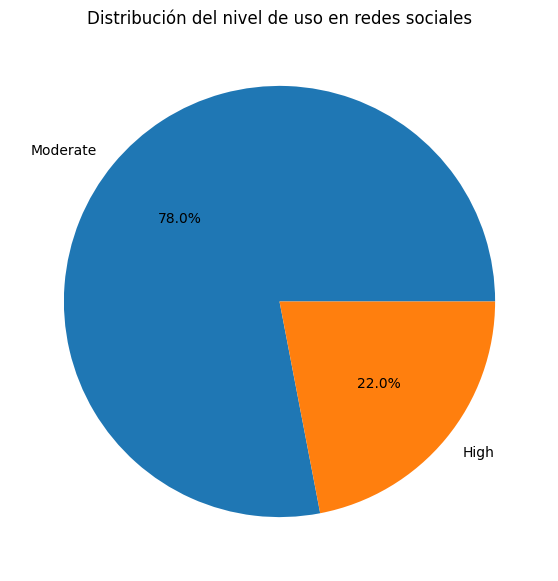

In [15]:
#Visualización pie chart

plt.figure(figsize=(7,7))

df['Usage_Level'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title('Distribución del nivel de uso en redes sociales')
plt.ylabel('')

plt.show()

- Se puede observar que el 78% de los usuarios pertenece a la categoría “Moderate”, lo que indica que la mayoría utiliza las redes sociales durante un tiempo moderado al día.

- Por otra parte, el 22% corresponde al nivel “High”, representando a los usuarios con un tiempo de uso superior a 120 minutos diarios.

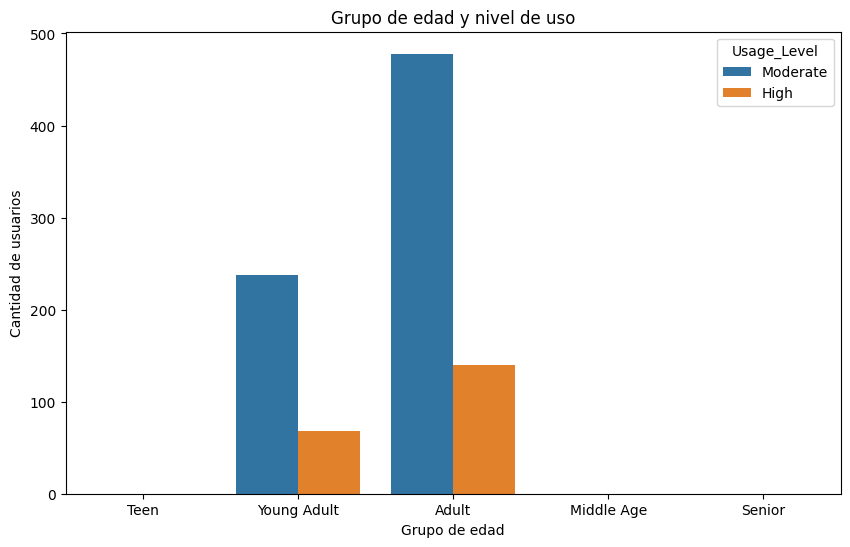

In [16]:
#Visualización por grupo de edad y el mivel de uso de las plataformas de redes sociales

plt.figure(figsize=(10,6))

sns.countplot(
    x='Age_Group',
    hue='Usage_Level',
    data=df
)

plt.title('Grupo de edad y nivel de uso de redes sociales')
plt.xlabel('Grupo de edad')
plt.ylabel('Cantidad de usuarios')

plt.show()

- Se puede observar que el grupo con mayor participación corresponde a los usuarios clasificados como “Adult”, especialmente dentro del nivel de uso “Moderate”.

- El grupo “Young Adult” también presenta una cantidad importante de usuarios, aunque en menor proporción respecto al grupo adulto.

- Los grupos “Teen”, “Middle Age” y “Senior” presentan una participación muy baja o nula dentro del dataset, lo que sugiere que la mayor parte de los registros analizados se concentra en usuarios jóvenes y adultos.

8. Conclusiones

- Se realizó un análisis de datos enfocado en el comportamiento de usuarios en redes sociales utilizando herramientas de análisis y visualización en Python y mediante el uso de la libreria pandas, se pudo cargar, limpiar y transformar el dataset para facilitar su interpretación.

- En la exploración inicial se identificaron valores nulos en algunas columnas, por lo que se aplicó un proceso de limpieza eliminando registros incompletos para garantizar un análisis más confiable y consistente.

- A través de las estadísticas descriptivas se observo que los usuarios dedican en promedio aproximadamente 96 minutos diarios al uso de redes sociales. Además, realizan cerca de 3 publicaciones por día y reciben alrededor de 40 “likes” diarios.

- El mapa de correlación mostro relaciones positivas entre las variables numéricas del dataset y la correlación más alta se presenta entre Daily_Usage_Time y Likes_Per_Day con un valor de 0.94, lo que se puede determinar que los usuarios que pasan más tiempo en redes sociales tienden a recibir una mayor cantidad de “likes” en sus publicaciones.

- Las variables Likes_Per_Day y Comments_Per_Day tuvieron una correlación de 0.93, evidenciando que las publicaciones con más “likes” también suelen generar más comentarios e interacción por parte de otros usuarios.

- El análisis por plataformas mostró que Instagram presenta los niveles más altos de interacción en comparación con otras redes sociales, mientras que LinkedIn mantiene una actividad más moderada debido a su enfoque profesional.

- Asi mismo la creación de nuevas columnas permitió enriquecer el análisis, facilitando la clasificación de usuarios según su nivel de uso, actividad y grupo de edad.